In [1]:
!pip install ta-lib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 95.7 MB/s eta 0:00:00


In [2]:
import talib as ta
import matplotlib.pyplot as plt
import seaborn as sns
import numpy
import yfinance as yf
import pandas as pd

In [5]:
stock = yf.Ticker('HDFCBANK.NS')
stock_data = stock.history(period = '7mo')

In [102]:
stock_data.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-08-28 00:00:00+05:30,967.000000,972.200012,955.000000,957.799988,25438255,0.0,0.0
2025-08-29 00:00:00+05:30,954.000000,963.299988,950.099976,951.599976,14823813,0.0,0.0
2025-09-01 00:00:00+05:30,949.599976,957.450012,946.349976,950.599976,20178344,0.0,0.0
2025-09-02 00:00:00+05:30,951.000000,954.799988,944.000000,944.500000,14196320,0.0,0.0
2025-09-03 00:00:00+05:30,945.000000,956.299988,940.000000,954.450012,16083481,0.0,0.0


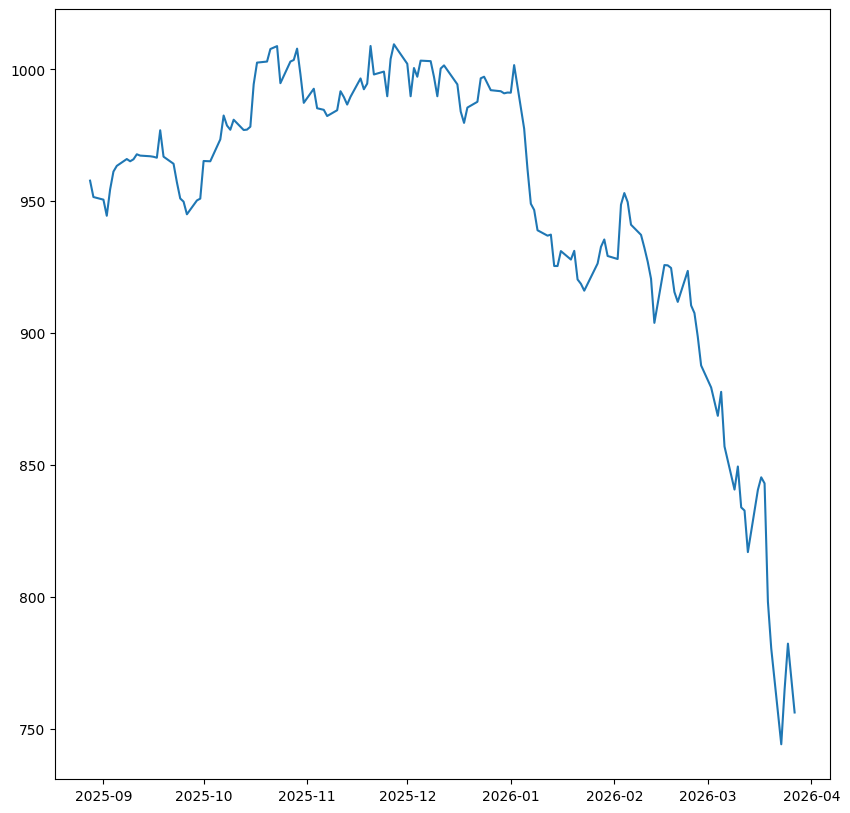

In [103]:
plt.figure(figsize = (10 , 10))
plt.plot(stock_data.Close)
plt.show()

CALCULATE THE 20 DAYS SMA


In [4]:
stock_data['SMA20'] = stock_data.Close.rolling(20).mean()

In [118]:
std = stock_data['Close'].rolling(20).std()

In [119]:
adx = ta.ADX(stock_data.High , stock_data.Low , stock_data.Close , timeperiod = 14)
stock_data['Plus_DI'] = ta.PLUS_DI(stock_data['High'], stock_data['Low'], stock_data['Close'], timeperiod=14)
stock_data['Minus_DI'] = ta.MINUS_DI(stock_data['High'], stock_data['Low'], stock_data['Close'], timeperiod=14)

In [121]:
std.shape

(118,)

In [120]:
std = std[27 : ]
adx = adx[27 : ]
stock_data = stock_data[27 : ]

In [123]:
adx.shape

(118,)

In [78]:
stock_data.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,SMA20
Date,,,,,,,,
2025-10-28 00:00:00+05:30,997.650024,1008.000000,995.000000,1003.549988,33904289,0.0,0.0,983.717502
2025-10-29 00:00:00+05:30,1004.900024,1012.500000,1000.000000,1007.849976,17769445,0.0,0.0,986.595001
2025-10-30 00:00:00+05:30,1000.000000,1009.500000,997.099976,998.150024,19962917,0.0,0.0,988.952502
2025-10-31 00:00:00+05:30,994.000000,1004.450012,981.150024,987.299988,23221330,0.0,0.0,990.055002
2025-11-03 00:00:00+05:30,985.000000,994.549988,983.299988,992.650024,16607180,0.0,0.0,991.430002


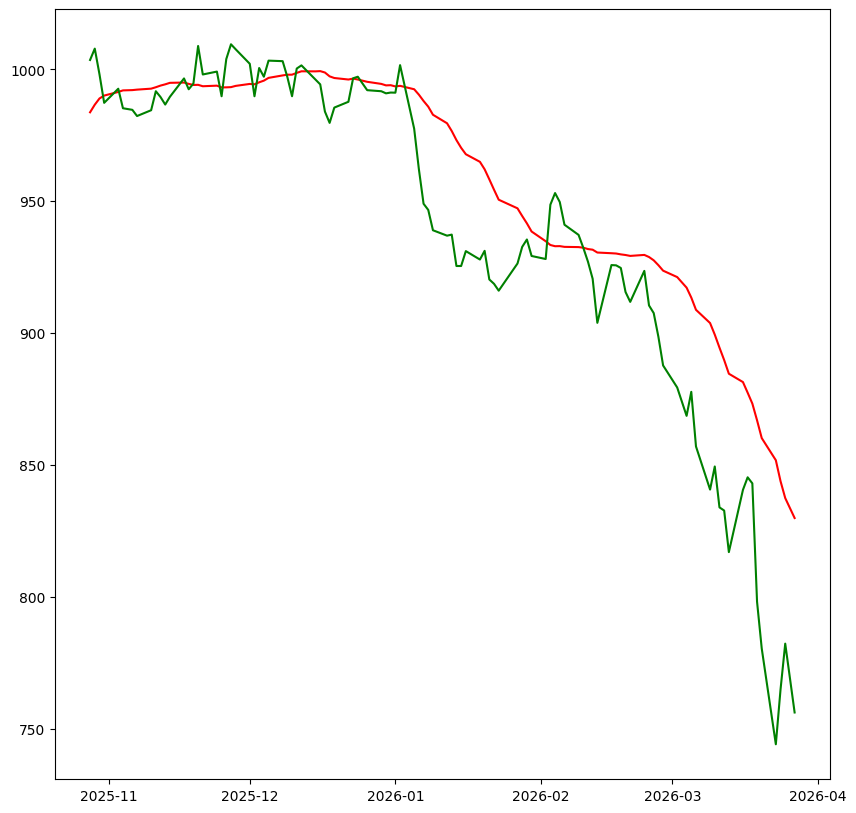

In [46]:
plt.figure(figsize = (10 , 10))
plt.plot(stock_data.SMA20 , color = 'red')
plt.plot(stock_data.Close , color = 'green')
plt.show()

In [124]:
def boll_bands(sma20 , std):
    upper_band = sma20 + 2 * std
    lower_band = sma20 - 2 * std
    return upper_band , lower_band

In [125]:
up , lo = boll_bands(stock_data.SMA20 , std)

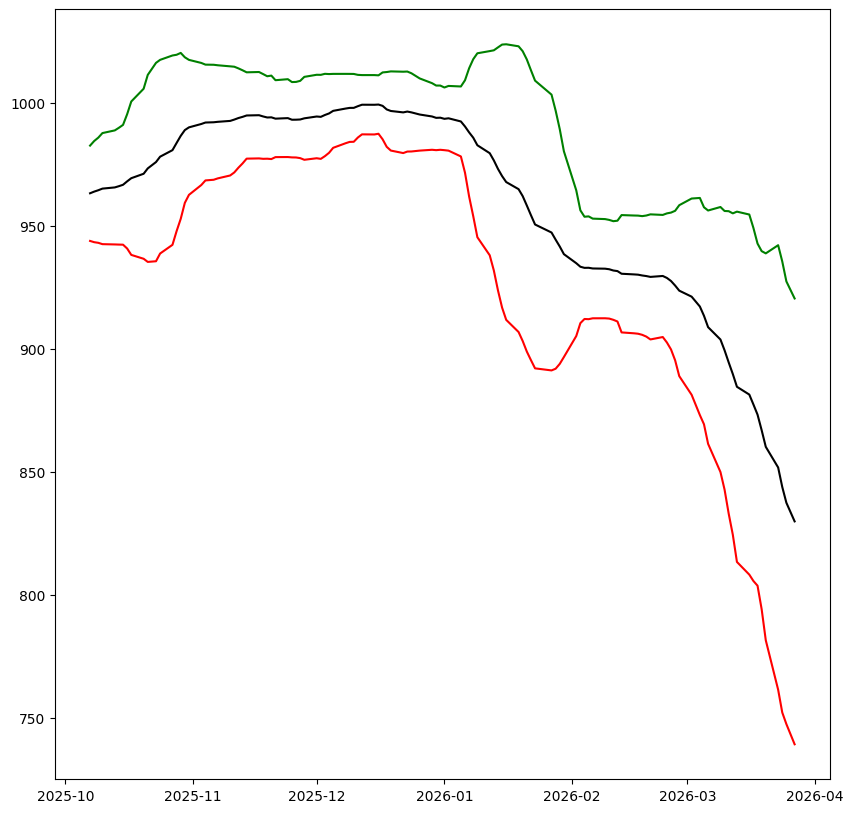

In [127]:
plt.figure(figsize = (10 , 10))
plt.plot(stock_data.SMA20 , color = 'black')
plt.plot(up , color = 'green')
plt.plot(lo , color = 'red')
plt.show()

In [128]:
stock_data['Plus_DI'].isnull().sum(0)
adx.isnull().sum(0)

np.int64(0)

In [6]:
!pip install backtesting

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.1/192.1 kB 12.1 MB/s eta 0:00:00


In [7]:
from backtesting import Backtest , Strategy
from backtesting.lib import crossover


/usr/local/lib/python3.12/dist-packages/backtesting/_plotting.py:55: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support, such as old IDEs. Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


In [8]:
class strategy(Strategy):
  period = 20
  adx_threshold = 20

  def init(self):
    high , low , close = self.data.High , self.data.Low , self.data.Close

    self.sma = self.I(lambda x : pd.Series(x).rolling(self.period).std(), close)
    self.sma50 = self.I(lambda x : pd.Series(x).rolling(50).mean(), close)
    self.sma200 = self.I(lambda x : pd.Series(x).rolling(200).mean(), close)

    self.std = self.I(lambda x: pd.Series(x).rolling(self.period).std(), close)

    self.rsi = self.I(ta.RSI , close , timeperiod = 14)
    self.upper_band = self.I(lambda : self.sma + (2 * self.std))
    self.lower_band = self.I(lambda : self.sma - (2 * self.std))

    self.adx = self.I(ta.ADX , high , low , close , timeperiod = 14)
    self.plus_di = self.I(ta.PLUS_DI , high , low , close , timeperiod = 14)
    self.minus_di = self.I(ta.MINUS_DI , high , low , close , timeperiod = 14)

  def next(self):
    adx = self.adx[-1]
    price = self.data.Close[-1]
    last_price = self.data.Close[-2]
    rsi = self.rsi[-1]
    last_rsi = self.rsi[-2]

    # sideways market
    if adx < 18:
      # touching the upper bb (go for short trade)
      if (price >= self.upper_band[-1] and last_price < self.upper_band[-2] and rsi >= 70):
        self.position.close()
        self.sell()

      # touching the lower bb (go for long trade)
      elif (price <= self.lower_band[-1] and last_price < self.upper_band[-2] and rsi <= 30):
        self.position.close()
        self.buy()

    elif adx >= self.adx_threshold :
      # trending market
      # check for the direction of trend

      # if number of buyers > sellers -> go for long trade
      if crossover(self.sma50 , self.sma200):
        self.position.close()
        self.buy()

      # if number of sellers > buyers -> go for short trade
      elif crossover(self.sma200 , self.sma50):
        self.position.close()
        self.sell()


In [9]:
class strategy(Strategy):
  period = 20
  adx_threshold = 22

  def init(self):
    high , low , close = self.data.High , self.data.Low , self.data.Close

    self.sma = self.I(lambda x : pd.Series(x).rolling(self.period).mean(), close)
    self.sma50 = self.I(lambda x : pd.Series(x).rolling(50).mean(), close)
    self.sma200 = self.I(lambda x : pd.Series(x).rolling(200).mean(), close)

    self.std = self.I(lambda x: pd.Series(x).rolling(self.period).std(), close)

    self.rsi = self.I(ta.RSI , close , timeperiod = 14)
    self.upper_band = self.I(lambda : self.sma + (2 * self.std))
    self.lower_band = self.I(lambda : self.sma - (2 * self.std))

    self.adx = self.I(ta.ADX , high , low , close , timeperiod = 14)
    self.plus_di = self.I(ta.PLUS_DI , high , low , close , timeperiod = 14)
    self.minus_di = self.I(ta.MINUS_DI , high , low , close , timeperiod = 14)

  def next(self):
    adx = self.adx[-1]
    price = self.data.Close[-1]
    last_price = self.data.Close[-2]
    rsi = self.rsi[-1]
    last_rsi = self.rsi[-2]

    # sideways market
    if adx < 20:
      # touching the upper bb (go for short trade)
      if (rsi > 60):
        self.position.close()
        self.sell()

      # touching the lower bb (go for long trade)
      elif (rsi < 40):
        self.position.close()
        self.buy()

    elif adx >= self.adx_threshold :
      # trending market
      # check for the direction of trend

      # if number of buyers > sellers -> go for long trade
      if crossover(self.plus_di , self.minus_di):
        self.position.close()
        self.buy()

      # if number of sellers > buyers -> go for short trade
      elif crossover(self.minus_di , self.plus_di):
        self.position.close()
        self.sell()


In [10]:
bt = Backtest(stock_data , strategy , cash = 10000 , commission = 0.005 , finalize_trades = True)
bt.run()

Backtest.run:   0%|          | 0/94 [00:00<?, ?bar/s]

,0
Start,2025-09-01 00:00:00+05:30
End,2026-03-30 00:00:00+05:30
Duration,210 days 00:00:00
Exposure Time [%],61.111111
Equity Final [$],11127.030157
Equity Peak [$],11174.790036
Commissions [$],544.869501
Return [%],11.270302
Buy & Hold Return [%],-26.068723
Return (Ann.) [%],20.549028


In [11]:
stats = bt.run()

Backtest.run:   0%|          | 0/94 [00:00<?, ?bar/s]

In [12]:
print(f"Total Return [%]:    {stats['Return [%]']:.2f}%")
print(f"Buy Hold Returns[%] : {stats['Buy & Hold Return [%]']:.2f}%")
print(f"Annualized Return:   {stats['Return (Ann.) [%]']:.2f}%")
print(f"Max Drawdown [%]:    {stats['Max. Drawdown [%]']:.2f}%")
print(f"Sharpe Ratio:        {stats['Sharpe Ratio']:.2f}")
print(f"Win Rate [%]:        {stats['Win Rate [%]']:.2f}%")
print(f"Profit factor :      {stats['Profit Factor']:.2f}")
print(f"Number of Trades:    {stats['# Trades']}")

Total Return [%]:    11.27%
Buy Hold Returns[%] : -26.07%
Annualized Return:   20.55%
Max Drawdown [%]:    -8.54%
Sharpe Ratio:        1.21
Win Rate [%]:        33.33%
Profit factor :      2.43
Number of Trades:    6


In [13]:
stats['_trades']

,Size,EntryBar,ExitBar,EntryPrice,ExitPrice,SL,TP,PnL,Commission,ReturnPct,...,"Entry_RSI(C,14)","Exit_RSI(C,14)",Entry_λ,Exit_λ,"Entry_ADX(H,L,C,14)","Exit_ADX(H,L,C,14)","Entry_PLUS_DI(H,L,C,14)","Exit_PLUS_DI(H,L,C,14)","Entry_MINUS_DI(H,L,C,14)","Exit_MINUS_DI(H,L,C,14)"
0,-9,56,61,1003.099976,1007.000000,None,None,-125.554719,90.454499,-0.013907,...,55.546389,59.026711,977.961628,976.876160,14.705646,13.799700,23.927964,21.075335,17.145118,16.118328
1,-9,61,88,1007.000000,956.000000,None,None,370.665000,88.335000,0.040899,...,59.026711,29.301605,976.876160,961.932496,13.799700,17.777309,21.075335,11.660117,16.118328,33.342200
2,10,88,89,956.000000,944.700012,None,None,-208.034879,95.035001,-0.021761,...,29.301605,28.574964,961.932496,953.932565,17.777309,20.148788,11.660117,10.950780,33.342200,33.726239
3,10,89,107,944.700012,952.500000,None,None,-16.860123,94.860001,-0.001785,...,28.574964,54.217048,953.932565,912.171779,20.148788,30.285689,10.950780,32.111065,33.726239,19.410550
4,10,107,114,952.500000,913.000000,None,None,-488.275000,93.275000,-0.051262,...,54.217048,30.040382,912.171779,906.713969,30.285689,22.542866,32.111065,21.032768,19.410550,30.395419
5,-10,114,143,913.000000,745.200012,None,None,1595.089877,82.910001,0.174709,...,30.040382,26.495873,906.713969,726.915645,22.542866,45.403958,21.032768,13.934782,30.395419,46.923277


In [16]:
bt.plot(filename="my_equity_curve.html", open_browser=True)

/usr/local/lib/python3.12/dist-packages/bokeh/util/serialization.py:242: UserWarning: no explicit representation of timezones available for np.datetime64
  return convert(array.astype("datetime64[us]"))


GridPlot(id='p2374', ...)